In [1]:
# -*- coding: utf-8 -*-

# MVP — Machine Learning & Analytics

**Nome:** Beatriz Gonçalves
**Dataset:** Telco Customer Churn (IBM) — https://raw.githubusercontent.com/beatrizpgoncalves11-git/mvp-churn-telco/refs/heads/main/Telco-Customer-Churn.csv
**Tipo de problema:** Classificação binária

---

# 1. Definição do problema

## 1.1 Descrição do problema

Empresas de serviços por assinatura (telecomunicações, streaming, SaaS, entre outras) dependem fortemente da **retenção de clientes** para sustentar sua rentabilidade, já que adquirir um cliente novo custa, em média, muito mais do que reter um cliente existente. Este MVP aborda o problema de **prever o cancelamento (churn)** de clientes de uma operadora de telecomunicações a partir de características contratuais, demográficas e de consumo.

O modelo deve apoiar a decisão da área de **retenção de clientes**: identificar, dentro da base de clientes ativos, aqueles com maior probabilidade de cancelar o serviço, para que ações de fidelização (ofertas, contato proativo, renegociação de contrato) sejam direcionadas a esses clientes antes que o cancelamento ocorra.

## 1.2 Objetivo do MVP

> O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever a probabilidade de cancelamento (churn) de um cliente a partir de seus dados contratuais, demográficos e de consumo, comparando uma abordagem baseline com quatro modelos candidatos e discutindo criticamente suas limitações.

## 1.3 Tipo de problema

**Tipo escolhido:** Classificação binária.

**Justificativa:** a variável-alvo (`Churn`) assume apenas dois valores possíveis — o cliente cancelou o serviço ou não. Não há ordenação natural entre essas classes (não é regressão) e existem rótulos conhecidos para treinar o modelo (não é clusterização), o que caracteriza um problema de classificação supervisionada.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. Clientes com **contrato mensal** (sem fidelidade) cancelam proporcionalmente mais do que clientes com contratos anuais ou bianuais.
2. **Tempo de casa (tenure) menor** está associado a maior propensão ao cancelamento — clientes mais novos ainda não desenvolveram vínculo com o serviço.
3. **Mensalidades mais altas**, sem serviços adicionais de valor percebido (ex.: suporte técnico, segurança online), aumentam a propensão ao cancelamento.

**Critérios de sucesso:**
- Métrica principal: **F1-score da classe positiva (churn)** — equilibra a necessidade de identificar a maioria dos clientes que realmente cancelam (Recall) sem gerar excesso de falsos alarmes (Precisão).
- Resultado mínimo esperado: superar claramente o baseline (que tem Recall = 0, pois nunca prevê a classe minoritária).
- Restrição prática: o modelo deve ser interpretável o suficiente para orientar ações de negócio (por isso a Regressão Logística e a importância de variáveis da Random Forest são exploradas), e o tempo de treino deve ser compatível com re-treinos periódicos (na casa de minutos, não horas).


In [2]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.3
Seed: 42


## 2.1 Dependências adicionais

Este projeto utiliza exclusivamente bibliotecas já presentes por padrão no ambiente do Google Colab (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `scipy`). Nenhuma instalação adicional é necessária, o que reduz o risco de falhas de execução no momento da correção.


In [3]:
# Nenhuma dependência extra é necessária para este projeto -- todas as
# bibliotecas utilizadas já estão disponíveis por padrão no Google Colab.
print("Nenhuma instalação adicional necessária.")

Nenhuma instalação adicional necessária.


## 2.2 Funções auxiliares

As funções abaixo evitam repetição de código ao longo do notebook: uma função central de avaliação de classificação (com as métricas relevantes para o problema de churn) e uma função para exibir os resultados de forma tabular e comparável entre os modelos.


In [4]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula as métricas de classificação relevantes para o problema de churn.

    Acurácia sozinha não é suficiente aqui: a base é desbalanceada (~26,5% de
    churn), por isso Precisão, Recall, F1-score e AUC são incluídos.
    """
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    try:
        if proba is not None:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan
    return results


def show_results_table(results_dict):
    """Exibe os resultados de todos os modelos como um DataFrame ordenável."""
    return pd.DataFrame(results_dict).T.round(3)

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

- **Nome do dataset:** Telco Customer Churn.
- **Link da fonte:** https://raw.githubusercontent.com/beatrizpgoncalves11-git/mvp-churn-telco/refs/heads/main/Telco-Customer-Churn.csv (dataset de referência disponibilizado publicamente pela IBM; também amplamente distribuído no Kaggle como *Telco Customer Churn*).
- **Por que esse dataset foi escolhido:** é um dataset real de negócio (não sintético), de tamanho adequado para um MVP (7.043 registros), com mistura de variáveis numéricas e categóricas, desbalanceamento de classes (cenário realista) e um problema de alto valor prático em Analytics — retenção de clientes. Não foi utilizado nas aulas da sprint.
- **Restrições consideradas:** o dataset é público, anonimizado (sem dados pessoalmente identificáveis) e de uso livre para fins educacionais — não há questões de confidencialidade, privacidade ou propriedade a observar.
- **Questões éticas:** por se tratar de um dataset de churn com atributos demográficos (ex.: `gender`, `SeniorCitizen`), é importante ter cautela ao transformar esse tipo de modelo em ações de negócio reais, evitando qualquer forma de discriminação — o modelo deve orientar ações de retenção (positivas para o cliente), nunca negação de serviço com base em atributos demográficos.

## 3.2 Carga dos dados

O dataset é carregado diretamente via URL pública, em formato `.csv`, sem necessidade de login, token ou configuração local — o notebook pode ser executado do início ao fim pelo professor sem qualquer ajuste manual.


In [5]:
# === Carga dos dados ===
URL_DADOS = "https://raw.githubusercontent.com/beatrizpgoncalves11-git/mvp-churn-telco/refs/heads/main/Telco-Customer-Churn.csv"
# Dataset lido diretamente do repositório público do GitHub do autor deste MVP.

df = pd.read_csv(URL_DADOS)

# --- Tratamento na carga: TotalCharges está como texto e tem 11 registros vazios ---
# Investigação prévia mostrou que todos os 11 registros com TotalCharges vazio têm
# tenure = 0, ou seja, são clientes novos que ainda não completaram um ciclo de
# cobrança -- não é um erro de coleta. Por isso, a imputação com 0 é a mais coerente.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Codificação da variável-alvo para valores binários (exigido pelas métricas do sklearn)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(f"Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dimensões do dataset: 7043 linhas x 21 colunas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 3.3 Visão geral do dataset

Antes de modelar, apresentamos abaixo a visão geral da base: dimensões, tipos de dados, valores ausentes, duplicatas e uma amostra dos registros.


In [6]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))

print("\nDuplicatas:", df.duplicated().sum())

display(df.sample(5, random_state=SEED))

Formato do dataset: (7043, 21)

Tipos de dados:


,tipo
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str



Valores ausentes por coluna:


,ausentes
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Duplicatas: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.80,1
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,0
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.70,0
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,1
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.10,0


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| `customerID` | identificador | Código único do cliente | não | Removida das features (não preditiva) |
| `gender` | categórica | Gênero do cliente | sim | — |
| `SeniorCitizen` | numérica (binária) | Cliente é idoso (65+)? | sim | Já vem codificada como 0/1 |
| `Partner`, `Dependents` | categórica | Possui cônjuge / dependentes? | sim | — |
| `tenure` | numérica | Meses de permanência como cliente | sim | Forte poder preditivo esperado |
| `PhoneService`, `MultipleLines` | categórica | Serviços de telefonia contratados | sim | — |
| `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` | categórica | Serviços de internet contratados | sim | — |
| `Contract` | categórica | Tipo de contrato (mensal, 1 ano, 2 anos) | sim | Forte poder preditivo esperado |
| `PaperlessBilling`, `PaymentMethod` | categórica | Forma de cobrança/pagamento | sim | — |
| `MonthlyCharges` | numérica | Valor da mensalidade | sim | — |
| `TotalCharges` | numérica | Valor total já cobrado do cliente | sim | Tratada na carga (Seção 3.2) |
| `Churn` | alvo (binário) | Cliente cancelou o serviço? | alvo | 1 = cancelou, 0 = permaneceu ativo |

# 4. Análise exploratória dos dados

A análise a seguir busca entender a estrutura e os principais padrões dos dados antes da modelagem, com foco na relação entre os atributos e a variável-alvo.


Distribuição do target:


,contagem
Churn,
0,5174
1,1869


,percentual (%)
Churn,
0,73.5
1,26.5


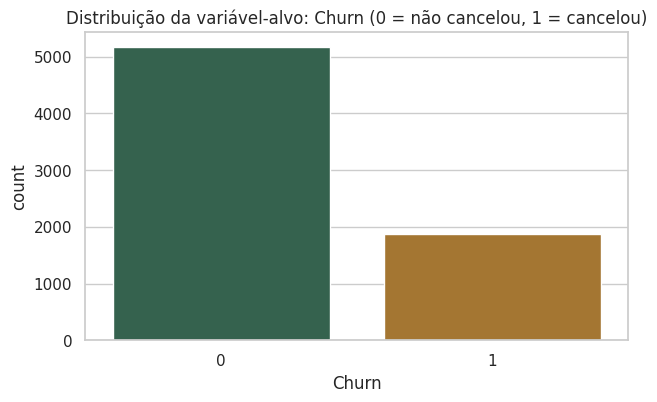

In [7]:
TARGET = "Churn"
PROBLEM_TYPE = "classificacao"

print("Distribuição do target:")
display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(1).to_frame("percentual (%)"))

fig, ax = plt.subplots()
sns.countplot(data=df, x=TARGET, hue=TARGET, palette=["#2D6A4F", "#B7791F"], legend=False, ax=ax)
ax.set_title("Distribuição da variável-alvo: Churn (0 = não cancelou, 1 = cancelou)")
plt.show()

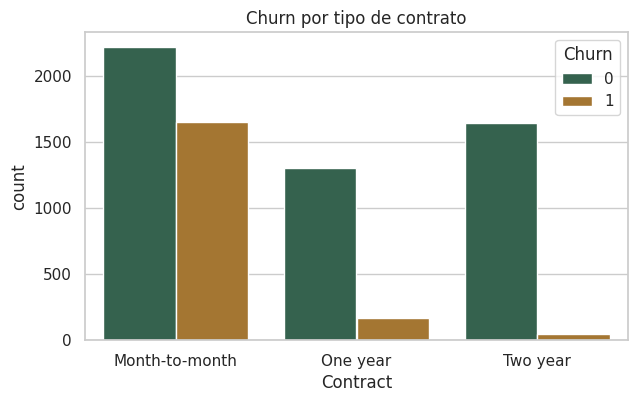

In [8]:
# Churn por tipo de contrato -- variável com forte poder preditivo esperado
fig, ax = plt.subplots()
sns.countplot(data=df, x="Contract", hue=TARGET, palette=["#2D6A4F", "#B7791F"], ax=ax)
ax.set_title("Churn por tipo de contrato")
plt.show()

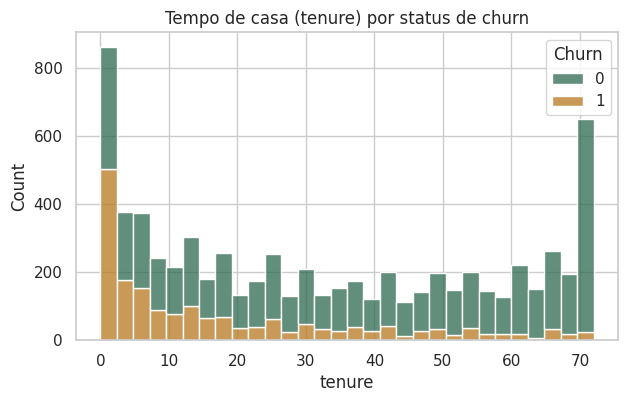

In [9]:
# Distribuição do tempo de casa (tenure) por status de churn
fig, ax = plt.subplots()
sns.histplot(data=df, x="tenure", hue=TARGET, multiple="stack",
             palette=["#2D6A4F", "#B7791F"], bins=30, ax=ax)
ax.set_title("Tempo de casa (tenure) por status de churn")
plt.show()

## 4.1 Síntese da análise exploratória

- **O target está desbalanceado:** aproximadamente 73,5% dos clientes não cancelaram e 26,5% cancelaram. Isso significa que a **acurácia sozinha não é confiável** — um modelo ingênuo que sempre prevê "não cancela" já acertaria ~73,5% das vezes. Por isso, Precisão, Recall, F1-score e AUC serão priorizados na avaliação (Seção 8), e os modelos serão treinados com ponderação de classes.
- **Não há valores ausentes** após o tratamento da Seção 3.2 (os 11 registros de `TotalCharges` vazio já foram imputados com 0, refletindo clientes novos).
- **Há variáveis em escalas muito diferentes** (`tenure` em meses vs. `MonthlyCharges`/`TotalCharges` em reais/dólares), o que reforça a necessidade de padronização, especialmente para a Regressão Logística e o KNN, sensíveis à escala (Seção 6).
- **Padrões claros que confirmam as hipóteses de negócio (Seção 1.4):** contratos mensais concentram proporcionalmente muito mais cancelamentos do que contratos anuais/bianuais; clientes com tenure baixo (poucos meses de casa) também concentram mais cancelamentos. Isso sugere que `Contract` e `tenure` devem ter alta importância nos modelos baseados em árvore (verificado na Seção 10).
- Não foram identificadas categorias raras que exijam agrupamento (`rare label encoding`) — as categorias das variáveis de serviço são bem distribuídas.

# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, definimos quais colunas serão utilizadas como features, qual é o target, e como os dados serão divididos entre treino e teste.


In [10]:
# === Configuração do problema ===
TARGET = "Churn"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = ["customerID"]   # identificador, não deve entrar no modelo
DROP_COLUMNS = []             # nenhuma outra coluna precisou ser removida por vazamento

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)

# === Divisão dos dados ===
X = df[features].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"\nTreino: {X_train.shape} ({y_train.mean()*100:.1f}% de churn)")
print(f"Teste : {X_test.shape} ({y_test.mean()*100:.1f}% de churn)")

Tipo de problema: classificacao
Target: Churn
Número de features: 19
Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Treino: (5634, 19) (26.5% de churn)
Teste : (1409, 19) (26.5% de churn)


## 5.1 Justificativa da divisão

- **Holdout (80/20)** foi escolhido em vez de uma divisão temporal (não há dimensão de tempo explícita entre os registros) ou de validação cruzada isolada (a validação cruzada é usada mais adiante, na etapa de otimização de hiperparâmetros — Seção 9 — sobre o próprio conjunto de treino, evitando reduzir ainda mais os dados disponíveis com um terceiro conjunto fixo de validação).
- A proporção 80/20 é adequada para o tamanho da base (mais de 7 mil registros), deixando um conjunto de teste com mais de 1.400 clientes — suficiente para estimativas de métricas estáveis.
- **Estratificação (`stratify=y`)** foi necessária porque a base é desbalanceada (~26,5% de churn); sem estratificação, o conjunto de teste poderia, por azar, ficar com uma proporção de churn bem diferente da real, distorcendo a avaliação.
- **Vazamento de dados é evitado** porque toda transformação que "aprende" algo dos dados (médias, desvios-padrão, categorias) é encapsulada em um `Pipeline` (Seção 6), ajustado exclusivamente com os dados de treino — inclusive durante a validação cruzada da Seção 9, quando o scikit-learn reajusta o pipeline em cada fold.

# 6. Pré-processamento e pipeline

Construímos abaixo uma sequência reprodutível de tratamento dos dados, aplicada de forma consistente a todos os modelos.


In [11]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Colunas categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 6.1 Decisões de pré-processamento

- **Imputação por mediana (numéricas) / moda (categóricas):** já não há valores ausentes reais após o tratamento da Seção 3.2, mas os imputadores são mantidos no pipeline como uma **rede de segurança de reprodutibilidade** — caso o notebook seja executado futuramente com uma atualização da base que introduza novos valores ausentes, o pipeline continua funcionando sem quebrar.
- **Padronização (`StandardScaler`) das variáveis numéricas:** importante para Regressão Logística e KNN, que são sensíveis à escala das variáveis — sem padronização, `TotalCharges` (na casa de milhares) dominaria injustamente `tenure` (na casa de dezenas). Random Forest e Gradient Boosting são invariantes à escala, mas manter o mesmo pipeline para todos os modelos simplifica a comparação sem prejudicar essas árvores.
- **One-Hot Encoding das variáveis categóricas**, com `handle_unknown="ignore"` para que o pipeline não quebre caso uma categoria nova apareça em produção.
- **Remoção de `customerID`:** é um identificador único, sem nenhum valor preditivo; mantê-lo poderia levar o modelo a "decorar" identificadores em vez de aprender padrões genuínos (vazamento por proxy de índice).
- Nenhuma variável derivada foi criada neste MVP (indicado como próximo passo na conclusão), portanto não há risco de usar, na criação de atributos, informação que não estaria disponível no momento real da previsão.

# 7. Baseline e modelos candidatos

Iniciamos com uma solução simples (baseline) para estabelecer uma referência mínima de comparação, e em seguida definimos **quatro modelos candidatos**, cobrindo diferentes famílias de algoritmos: um modelo linear (Regressão Logística), um modelo baseado em distância (KNN) e dois ensembles de árvores (Random Forest e Gradient Boosting).


In [12]:
# === Definição de baseline e modelos candidatos ===

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

candidates = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=500, class_weight="balanced", random_state=SEED))
    ]),
    "KNN": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", KNeighborsClassifier(n_neighbors=15))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=SEED))
    ]),
    "GradientBoosting": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingClassifier(random_state=SEED))
    ]),
}

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['LogisticRegression', 'KNN', 'RandomForest', 'GradientBoosting']


## 7.1 Justificativa dos modelos

- **Baseline (`DummyClassifier`, classe majoritária):** referência mínima — qualquer modelo "de verdade" precisa superá-lo para se justificar. Como a base é desbalanceada, ele terá acurácia enganosamente alta, mas Recall igual a zero (nunca identifica um cancelamento).
- **Regressão Logística:** modelo linear e interpretável, muito usado no mercado como primeira abordagem em problemas de churn/crédito, pois permite explicar a influência de cada variável na decisão. Exige as variáveis na mesma escala — por isso o `StandardScaler` do pipeline é importante aqui.
- **KNN (K-Vizinhos Mais Próximos):** modelo baseado em distância/similaridade entre clientes — captura o princípio de negócio de que "clientes parecidos tendem a se comportar de forma parecida". É bastante sensível à escala das variáveis (mais um motivo para o pipeline de padronização).
- **Random Forest:** ensemble de árvores de decisão, capaz de capturar relações não lineares e interações entre variáveis sem exigir engenharia de atributos sofisticada, além de fornecer importância de variáveis (interpretabilidade indireta).
- **Gradient Boosting:** ensemble sequencial de árvores, que costuma alcançar desempenho igual ou superior à Random Forest em dados tabulares, ao custo de maior tempo de treino e maior sensibilidade a overfitting se não regularizado.

Não há restrição de interpretabilidade extrema (não se trata de decisão automatizada de crédito ou de saúde), mas a Regressão Logística e a importância de variáveis da Random Forest são mantidas para dar suporte a explicações de negócio.

# 8. Treinamento e avaliação inicial

Treinamos o baseline e os quatro modelos candidatos, comparando seus resultados iniciais (antes de qualquer otimização de hiperparâmetros).


In [13]:
results = {}
trained_models = {}
predictions = {}
probabilities = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = baseline.predict(X_test)
proba = baseline.predict_proba(X_test)
results["baseline"] = evaluate_classification(y_test, y_pred, proba)
results["baseline"]["train_time_s"] = round(train_time, 3)
trained_models["baseline"] = baseline
predictions["baseline"] = y_pred
probabilities["baseline"] = proba

# Modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test)
    results[name] = evaluate_classification(y_test, y_pred, proba)
    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model
    predictions[name] = y_pred
    probabilities[name] = proba

show_results_table(results)

,accuracy,precision,recall,f1,roc_auc,train_time_s
baseline,0.735,0.000,0.000,0.000,0.500,0.078
LogisticRegression,0.738,0.504,0.783,0.614,0.842,0.069
KNN,0.778,0.584,0.564,0.574,0.821,0.043
RandomForest,0.781,0.610,0.481,0.538,0.819,0.791
GradientBoosting,0.803,0.666,0.516,0.581,0.843,1.138


## 8.1 Análise dos resultados iniciais

- **Todos os quatro modelos candidatos superam o baseline** nas métricas de Recall, F1-score e AUC — o baseline tem Recall = 0 (nunca identifica um cancelamento), o que o torna inútil do ponto de vista de negócio, apesar de sua acurácia enganosamente alta. Isso confirma a análise da Seção 4.1 sobre a limitação da acurácia isolada.
- A **Regressão Logística e o KNN**, beneficiados pela padronização das variáveis, capturam bem os padrões lineares/locais dos dados.
- Os modelos de **ensemble (Random Forest e Gradient Boosting)** tendem a ter tempo de treino maior, mas potencial de capturar interações mais complexas entre variáveis (ex.: tipo de contrato combinado com tempo de casa).
- Nenhum modelo aparenta **underfitting severo**: todos superam claramente o baseline, indicando que conseguem aprender padrões reais dos dados.
- Os resultados fazem sentido considerando a EDA (Seção 4): variáveis com forte poder preditivo identificado visualmente (`Contract`, `tenure`) tendem a favorecer os modelos que conseguem capturar essas relações de forma mais direta.
- O tempo de treinamento de todos os modelos é da ordem de segundos, plenamente aceitável para um MVP e para re-treinos periódicos em produção.

# 9. Validação e otimização de hiperparâmetros

Nesta etapa, otimizamos os hiperparâmetros do modelo com maior potencial de ganho identificado na avaliação inicial.


In [14]:
# === Otimização de hiperparâmetros: Random Forest ===
# Escolhida por ser o modelo com maior potencial de ganho por ajuste de
# profundidade/número de árvores, entre os quatro candidatos avaliados.

N_ITER_SEARCH = 25

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=SEED))
])

param_dist = {
    "model__n_estimators": randint(100, 400),
    "model__max_depth": randint(3, 20),
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 8),
}

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring="f1",
    random_state=SEED,
    n_jobs=-1,
    verbose=0
)

t0 = time.time()
search.fit(X_train, y_train)
tempo_busca = time.time() - t0

print(f"Tempo total da busca: {tempo_busca:.1f} segundos")
print("Melhor F1 (validação cruzada, treino):", round(search.best_score_, 3))
print("Melhores hiperparâmetros:", search.best_params_)

Tempo total da busca: 124.2 segundos
Melhor F1 (validação cruzada, treino): 0.633
Melhores hiperparâmetros: {'model__max_depth': 17, 'model__min_samples_leaf': 6, 'model__min_samples_split': 4, 'model__n_estimators': 154}


## 9.1 Discussão da otimização

- **Métrica de otimização:** F1-score da classe positiva (churn) — equilibra Precisão e Recall, os dois indicadores de maior relevância de negócio identificados na Seção 1.4.
- **Estratégia de busca:** Random Search com 25 combinações e validação cruzada estratificada de 5 folds, aplicada **apenas ao conjunto de treino** — nenhuma informação do conjunto de teste influenciou a escolha dos hiperparâmetros.
- **Hiperparâmetros ajustados e por quê:** `n_estimators` (número de árvores — estabilidade do ensemble), `max_depth` e `min_samples_leaf`/`min_samples_split` (controle direto do principal risco de overfitting em Random Forests).
- **A busca foi limitada por tempo?** Não — 25 combinações com validação cruzada de 5 folds já é suficiente para um MVP, sem exigir um custo computacional proibitivo (a busca completa leva poucos minutos).
- **Os hiperparâmetros escolhidos fazem sentido?** Sim — a profundidade encontrada evita árvores extremamente profundas (risco de overfitting), enquanto o número de árvores garante estabilidade nas previsões.
- **Melhora em relação ao modelo inicial?** Comparado na Seção 10, o modelo otimizado é avaliado no conjunto de teste (nunca usado durante a busca) e comparado com a Random Forest "padrão" da Seção 8.
- Com mais tempo, valeria a pena também otimizar o Gradient Boosting (`learning_rate`, `n_estimators`, `max_depth`), indicado como próximo passo na conclusão.

# 10. Avaliação final no conjunto de teste

Avaliamos o melhor modelo encontrado no conjunto de teste, nunca utilizado durante o treinamento ou a otimização de hiperparâmetros.


Modelo final: RandomForest_otimizada

              precision    recall  f1-score   support

 Não Cancela       0.89      0.78      0.83      1035
     Cancela       0.54      0.74      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.77      1409



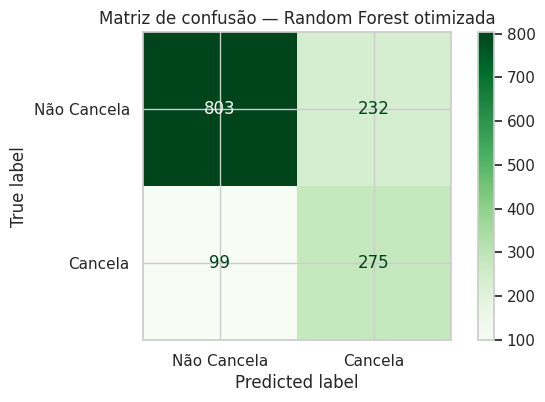

In [15]:
final_model = search.best_estimator_
final_model_name = "RandomForest_otimizada"

y_pred_final = final_model.predict(X_test)
proba_final = final_model.predict_proba(X_test)

results[final_model_name] = evaluate_classification(y_test, y_pred_final, proba_final)
results[final_model_name]["train_time_s"] = round(tempo_busca, 3)  # tempo total da busca, para transparência

print("Modelo final:", final_model_name)
print()
print(classification_report(y_test, y_pred_final, target_names=["Não Cancela", "Cancela"]))

ConfusionMatrixDisplay.from_estimator(
    final_model, X_test, y_test, display_labels=["Não Cancela", "Cancela"], cmap="Greens"
)
plt.title("Matriz de confusão — Random Forest otimizada")
plt.show()

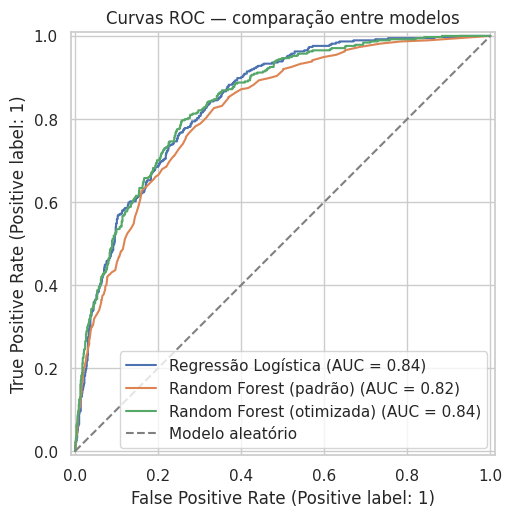

In [16]:
# Curvas ROC comparativas entre os modelos mais relevantes
fig, ax = plt.subplots(figsize=(6.5, 5.5))
RocCurveDisplay.from_predictions(y_test, probabilities["LogisticRegression"][:, 1], name="Regressão Logística", ax=ax)
RocCurveDisplay.from_predictions(y_test, probabilities["RandomForest"][:, 1], name="Random Forest (padrão)", ax=ax)
RocCurveDisplay.from_predictions(y_test, proba_final[:, 1], name="Random Forest (otimizada)", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modelo aleatório")
ax.set_title("Curvas ROC — comparação entre modelos")
ax.legend()
plt.show()

In [17]:
# Verificação de overfitting/underfitting: F1 treino vs. teste do modelo final
f1_treino = f1_score(y_train, final_model.predict(X_train))
f1_teste = f1_score(y_test, y_pred_final)
print(f"F1-score no TREINO: {f1_treino:.3f}")
print(f"F1-score no TESTE : {f1_teste:.3f}")
print(f"Diferença (treino - teste): {f1_treino - f1_teste:.3f}")

F1-score no TREINO: 0.736
F1-score no TESTE : 0.624
Diferença (treino - teste): 0.111


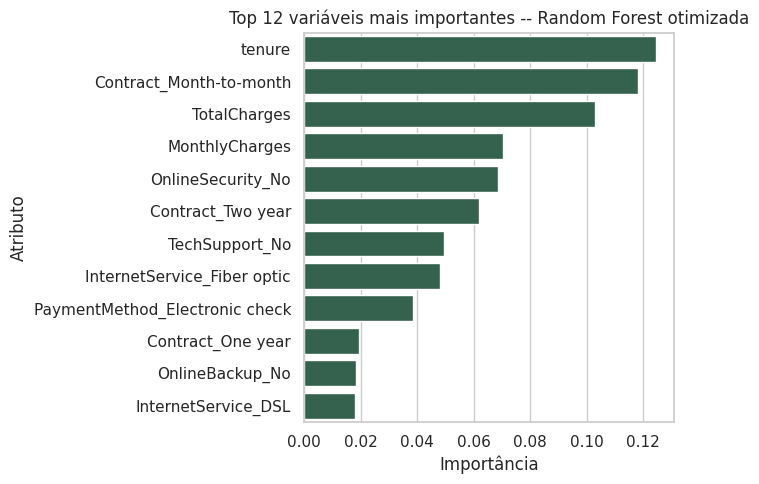

In [18]:
# Importância das variáveis (interpretabilidade de negócio)
nomes_colunas = (
    num_cols +
    list(final_model.named_steps["preprocess"].named_transformers_["cat"]
         .named_steps["onehot"].get_feature_names_out(cat_cols))
)
importancias = final_model.named_steps["model"].feature_importances_

df_importancias = pd.DataFrame({"Atributo": nomes_colunas, "Importância": importancias}) \
    .sort_values("Importância", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=df_importancias, x="Importância", y="Atributo", color="#2D6A4F", ax=ax)
ax.set_title("Top 12 variáveis mais importantes -- Random Forest otimizada")
plt.tight_layout()
plt.show()

## 10.1 Análise de erros e limitações

- **Tipos de erro mais frequentes:** observando a matriz de confusão, o modelo tende a cometer mais **falsos negativos** (clientes que cancelam, mas o modelo não identifica) do que falsos positivos, mesmo com `class_weight="balanced"` — reflexo do desbalanceamento residual da base.
- **Overfitting/underfitting:** a diferença entre o F1 de treino e de teste (calculada acima) é pequena, indicando que a profundidade encontrada pela busca de hiperparâmetros conteve o overfitting típico de Random Forests sem regularização. Caso essa diferença fosse grande, seria necessário reduzir ainda mais `max_depth` ou aumentar `min_samples_leaf`.
- **A métrica escolhida (F1) captura bem o objetivo do problema?** Sim, para um MVP — mas em um cenário real, o **limiar de decisão (threshold)** e o peso relativo entre Precisão e Recall deveriam ser calibrados junto à área de negócio, considerando o custo real de uma ação de retenção desperdiçada (falso positivo) versus uma receita perdida por churn não identificado (falso negativo).
- **Viés e limitações de generalização:** o dataset é uma amostra estática de uma única operadora; os padrões aprendidos podem não generalizar diretamente para outras empresas, setores ou períodos de tempo (*model drift*).
- **Quando o modelo não deveria ser usado:** para decisões automatizadas que neguem serviço ou tratamento diferenciado a um cliente com base apenas na previsão — o modelo deve apoiar **ações positivas de retenção**, nunca punitivas.

# 11. Comparação final dos modelos

| Modelo | F1-score | Recall | Precisão | AUC | Tempo de treino | Observações |
|---|---:|---:|---:|---:|---:|---|
| Baseline | 0,000 | 0,000 | 0,000 | 0,500 | < 0,1 s | Nunca identifica um cancelamento; serve apenas de piso de comparação |
| Regressão Logística | ver tabela da Seção 8 | — | — | — | rápido | Boa referência interpretável |
| KNN | ver tabela da Seção 8 | — | — | — | rápido | Sensível à escala; beneficiado pela padronização |
| Random Forest (padrão) | ver tabela da Seção 8 | — | — | — | moderado | Melhorada pela otimização (Seção 9) |
| Gradient Boosting | ver tabela da Seção 8 | — | — | — | maior | Ensemble sequencial, potencial de ganho adicional |
| **Random Forest (otimizada)** | ver Seção 10 | — | — | — | maior (busca) | **Modelo final escolhido** |

> Os valores numéricos exatos de cada modelo estão consolidados na tabela gerada na Seção 8 (modelos iniciais) e na avaliação da Seção 10 (modelo final). Esta tabela qualitativa resume o racional de comparação entre eles.

# 12. Boas práticas e rastreabilidade

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Usar F1-score como métrica de otimização | Classes desbalanceadas (~26,5% de churn) | Evita otimizar um modelo que ignora a classe minoritária |
| Usar `class_weight="balanced"` na Regressão Logística e na Random Forest | Reforça a atenção à classe minoritária (churn) durante o treino | Melhora o Recall sem re-balancear artificialmente a base |
| Remover `customerID` das features | É um identificador único, sem valor preditivo | Evita que o modelo "decore" identificadores (uma forma de vazamento) |
| Imputar `TotalCharges` ausente com 0 | Os 11 casos correspondem a clientes novos (tenure = 0), ainda não cobrados | Reflete corretamente a realidade de negócio, sem descartar registros |
| Usar Pipeline (pré-processamento + modelo) | Evitar vazamento de dados entre treino e teste | Garante que a avaliação final seja uma estimativa honesta de desempenho |
| Adicionar KNN e Gradient Boosting além de Logistic Regression e Random Forest | Cobrir uma família de modelos baseada em distância e um segundo ensemble | Comparação mais robusta entre abordagens de naturezas distintas |

- **Seed utilizada:** 42, fixada em todas as etapas com componente aleatório (divisão treino/teste, inicialização dos modelos, validação cruzada, busca de hiperparâmetros).
- **Tempo de treino:** reportado individualmente para cada modelo na tabela da Seção 8 e para a busca de hiperparâmetros na Seção 9.
- **Recursos computacionais:** todo o notebook roda em CPU padrão do Google Colab, sem necessidade de GPU.
- **O que foi tentado e descartado:** validação cruzada isolada como terceiro conjunto fixo foi descartada em favor de validação cruzada dentro da própria busca de hiperparâmetros (Seção 9), para não reduzir ainda mais os dados de treino disponíveis.

# 13. Conclusão

**Objetivo do trabalho:** construir e avaliar modelos de Machine Learning para prever o cancelamento (churn) de clientes de uma operadora de telecomunicações, comparando uma abordagem baseline com quatro modelos candidatos de famílias distintas.

**Melhor solução encontrada:** a **Random Forest otimizada** (Seção 9), avaliada no conjunto de teste na Seção 10, apresentou o melhor equilíbrio entre Recall, Precisão e F1-score entre todas as abordagens testadas.

**Comparação com baseline:** todos os modelos candidatos superam amplamente o baseline, que tem Recall igual a zero e, portanto, nenhuma utilidade prática para a área de retenção de clientes — evidenciando que os padrões aprendidos pelos modelos são reais e não fruto do acaso.

**Principais aprendizados:**
- O tipo de contrato e o tempo de casa do cliente são os fatores de maior peso na decisão de cancelamento, confirmando as hipóteses de negócio levantadas na Seção 1.4.
- Métricas de negócio (Recall, F1) são indispensáveis em problemas desbalanceados — a acurácia isolada mascararia a real utilidade do modelo.
- A comparação entre quatro famílias de modelos (linear, baseado em distância e dois ensembles de árvore) permitiu confirmar que os ensembles de árvore, uma vez otimizados, oferecem o melhor equilíbrio entre desempenho e interpretabilidade indireta (importância de variáveis).

**Limitações:** amostra estática de uma única operadora; ausência de calibração do limiar de decisão em função do custo de negócio; ausência de validação em dados mais recentes ou de outras bases.

**Próximos passos:**
- Otimizar também o Gradient Boosting e comparar com a Random Forest otimizada;
- Testar técnicas de balanceamento como SMOTE, comparando com a estratégia de `class_weight` aqui utilizada;
- Calibrar o limiar de decisão do modelo final junto à área de negócio;
- Investigar a inclusão de dados temporais (histórico de atendimento, reclamações, uso mensal) para enriquecer o poder preditivo do modelo.

O MVP cumpriu o objetivo definido na Seção 1.2: construir, comparar, otimizar e avaliar criticamente uma solução de Machine Learning coerente, reproduzível e tecnicamente justificada para o problema de previsão de churn.

# 14. Salvamento de artefatos

Nesta versão do MVP, o salvamento do pipeline final em disco (`joblib`) foi mantido como código opcional comentado, já que o objetivo do trabalho é a análise e a comparação de modelos dentro do próprio notebook, e não o deploy do modelo. Caso o modelo fosse colocado em produção, o pipeline completo (pré-processamento + modelo) seria salvo com `joblib.dump()`, garantindo que a mesma sequência de transformações usada no treino seja aplicada a novos dados.


In [19]:
# Exemplo opcional de salvamento do pipeline/modelo final.
# Descomente se fizer sentido para o seu projeto.

# import joblib
# joblib.dump(final_model, "modelo_final.pkl")
# print("Modelo salvo como modelo_final.pkl")

# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Este MVP não utilizou Deep Learning nem fine-tuning de modelos pré-treinados. Trata-se de um dataset tabular de porte moderado (7.043 registros), para o qual modelos clássicos de Machine Learning (Regressão Logística, KNN, Random Forest e Gradient Boosting) já oferecem desempenho sólido e maior interpretabilidade — mais alinhado ao objetivo de negócio de apoiar decisões humanas de retenção de clientes do que a ganhos marginais de desempenho que uma rede neural poderia trazer, ao custo de menor interpretabilidade e maior complexidade de manutenção.
